In [17]:
# Import necessary libraries
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from collections import Counter
from tensorflow.keras.models import Model


In [13]:
# Step 1: Define paths to folders (بدون نیاز به CSV)
train_image_path  = "../input/17flowerclasses/17flowerclasses/train/"   # فولدر آموزشی با زیرفولدرهای کلاس‌ها
test_image_path  = "../input/17flowerclasses/17flowerclasses/test/"   # فولدر تست با زیرفولدرهای کلاس‌ها


# Step 2: Data Augmentation and Preprocessing
IMG_SIZE = 224  # اندازه تصویر (برای MobileNetV2)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=35,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.3,
    zoom_range=0.4,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    validation_split=0.2
)

# برای Test، بدون افزایش داده
test_datagen = ImageDataGenerator(rescale=1./255)

# Step 3: Create generators from directories
train_generator = train_datagen.flow_from_directory(
    train_image_path,  # مسیر فولدر train
    target_size=(IMG_SIZE, IMG_SIZE),  # تغییر اندازه تصاویر
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # برای طبقه‌بندی چندکلاسه (one-hot encoding خودکار)
    shuffle=True,  # مخلوط کردن داده‌ها
    subset='training'  # اگر validation_split استفاده کردید
)

val_generator = train_datagen.flow_from_directory(  # یا val_datagen اگر فولدر جدا دارید
    train_image_path ,  # اگر val_dir وجود ندارد، از train استفاده کنید
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  # برای validation بهتر است shuffle نکنید
    subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_image_path,  # مسیر فولدر train
    target_size=(IMG_SIZE, IMG_SIZE),  # تغییر اندازه تصاویر
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # برای طبقه‌بندی چندکلاسه (one-hot encoding خودکار)
    shuffle=False,  # مخلوط کردن داده‌ها
    )
# چک کردن کلاس‌ها (اختیاری)
print(" کلاس‌های شناسایی‌شده در آموزش:", train_generator.class_indices)  # خروجی: {'class0': 0, 'class1': 1, ...}
print(" کلاس‌های شناسایی‌شده در تست:", test_generator.class_indices)  # خروجی: {'class0': 0, 'class1': 1, ...}


Found 952 images belonging to 17 classes.
Found 238 images belonging to 17 classes.
Found 170 images belonging to 17 classes.
 کلاس‌های شناسایی‌شده در آموزش: {'Bluebell': 0, 'ButterCup': 1, 'ColtsFoot': 2, 'Cowslip': 3, 'Crocus': 4, 'Daffodil': 5, 'Daisy': 6, 'Dandelion': 7, 'Fritillary': 8, 'Iris': 9, 'LilyValley': 10, 'Pansy': 11, 'Snowdrop': 12, 'Sunflower': 13, 'Tigerlily': 14, 'WindFlower': 15, 'tulip': 16}
 کلاس‌های شناسایی‌شده در تست: {'Bluebell': 0, 'ButterCup': 1, 'ColtsFoot': 2, 'Cowslip': 3, 'Crocus': 4, 'Daffodil': 5, 'Daisy': 6, 'Dandelion': 7, 'Fritillary': 8, 'Iris': 9, 'LilyValley': 10, 'Pansy': 11, 'Snowdrop': 12, 'Sunflower': 13, 'Tigerlily': 14, 'WindFlower': 15, 'tulip': 16}


تصاویر رندوم از Train:


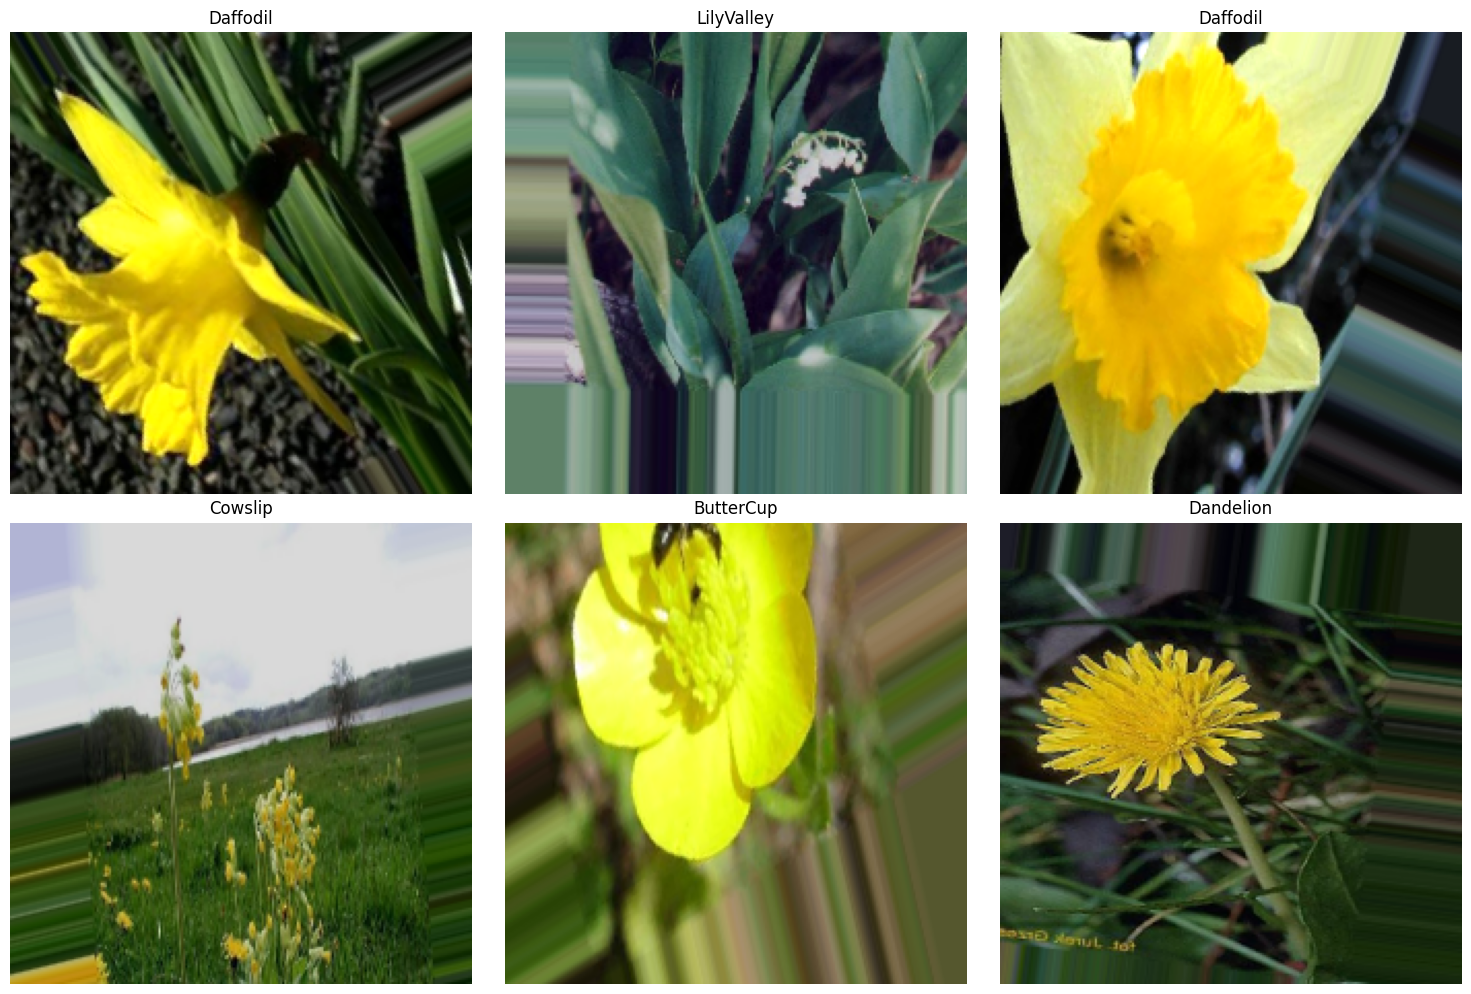

تصاویر رندوم از Validation:


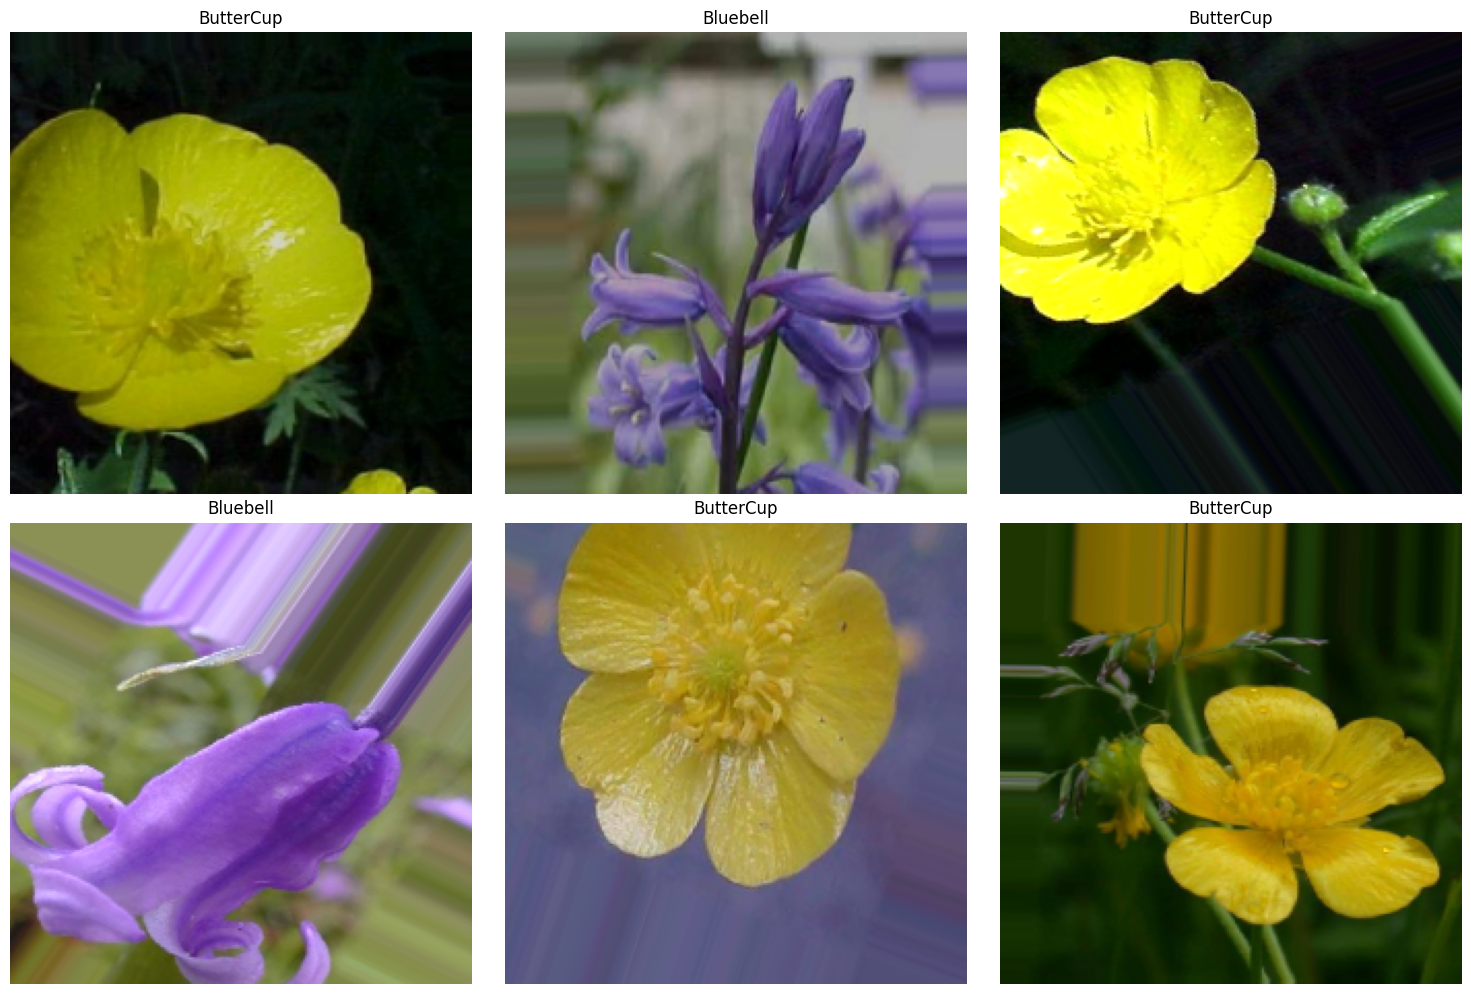

تصاویر رندوم از Test:


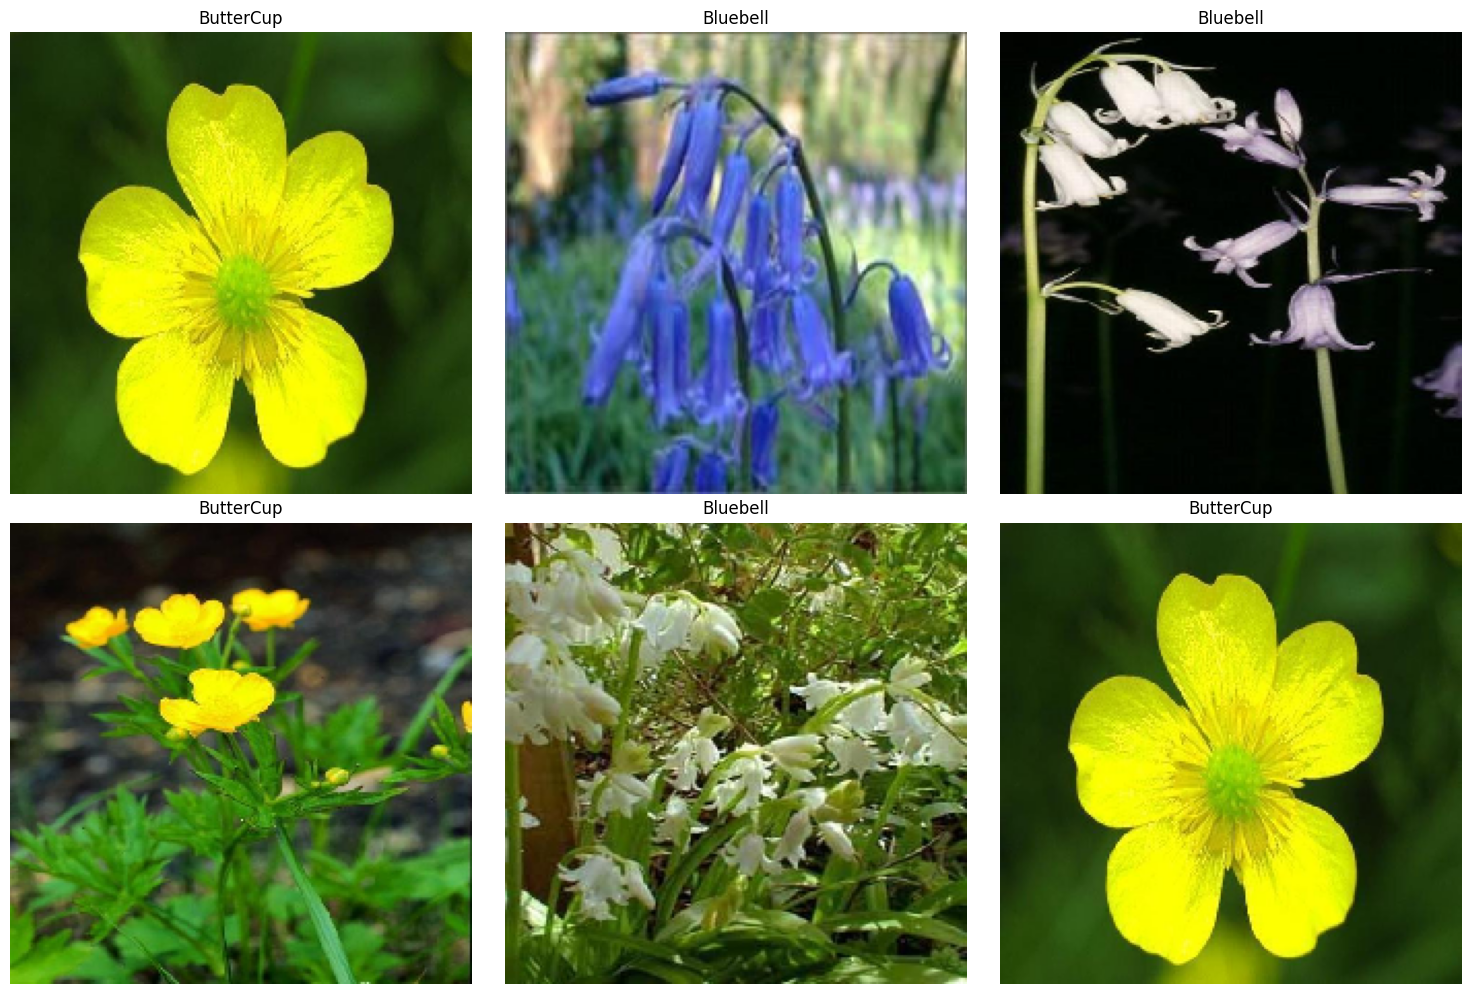

In [14]:
## ۲. نمایش چند عکس رندوم از هر ژنراتور

def plot_random_images(generator, num_images=6, cols=3):
    # یک بچ از داده‌ها رو بگیریم
    images, labels = next(generator)
    
    # انتخاب تصادفی چند تصویر
    indices = np.random.choice(len(images), size=min(num_images, len(images)), replace=False)
    
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(15, 5 * rows))
    
    class_names = {v: k for k, v in generator.class_indices.items()}
    
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[idx])
        label_idx = np.argmax(labels[idx])  # چون one-hot هست
        plt.title(f"{class_names[label_idx]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# نمایش 6 تصویر رندوم از train
print("تصاویر رندوم از Train:")
plot_random_images(train_generator, num_images=6)

# از validation
print("تصاویر رندوم از Validation:")
plot_random_images(val_generator, num_images=6)

# از test
print("تصاویر رندوم از Test:")
plot_random_images(test_generator, num_images=6)


In [15]:
# === بررسی توزیع کلاس‌ها ===
def get_class_distribution(generator):
    labels = generator.labels
    class_counts = Counter(labels)
    class_names = {v: k for k, v in generator.class_indices.items()}
    return {class_names[i]: class_counts[i] for i in class_counts}, generator.samples

train_dist, train_total = get_class_distribution(train_generator)
val_dist, val_total = get_class_distribution(val_generator)
test_dist, test_total = get_class_distribution(test_generator)

print(f"Train ({train_total}):", train_dist)
print(f"Val ({val_total}):", val_dist)
print(f"Test ({test_total}):", test_dist)


Train (952): {'Bluebell': 56, 'ButterCup': 56, 'ColtsFoot': 56, 'Cowslip': 56, 'Crocus': 56, 'Daffodil': 56, 'Daisy': 56, 'Dandelion': 56, 'Fritillary': 56, 'Iris': 56, 'LilyValley': 56, 'Pansy': 56, 'Snowdrop': 56, 'Sunflower': 56, 'Tigerlily': 56, 'WindFlower': 56, 'tulip': 56}
Val (238): {'Bluebell': 14, 'ButterCup': 14, 'ColtsFoot': 14, 'Cowslip': 14, 'Crocus': 14, 'Daffodil': 14, 'Daisy': 14, 'Dandelion': 14, 'Fritillary': 14, 'Iris': 14, 'LilyValley': 14, 'Pansy': 14, 'Snowdrop': 14, 'Sunflower': 14, 'Tigerlily': 14, 'WindFlower': 14, 'tulip': 14}
Test (170): {'Bluebell': 10, 'ButterCup': 10, 'ColtsFoot': 10, 'Cowslip': 10, 'Crocus': 10, 'Daffodil': 10, 'Daisy': 10, 'Dandelion': 10, 'Fritillary': 10, 'Iris': 10, 'LilyValley': 10, 'Pansy': 10, 'Snowdrop': 10, 'Sunflower': 10, 'Tigerlily': 10, 'WindFlower': 10, 'tulip': 10}


**ساخت مدل**

In [23]:
# --- تنظیمات ---
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 17
EPOCHS = 20
EPOCHS_INITIAL = 50
EPOCHS_FINE = 40
# --- ساخت مدل ---

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)       
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
predictions = Dense(17, activation='softmax')(x)
"""
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
# فریز کامل در ابتدا
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x) 
x = BatchNormalization()(x)
x = Dropout(0.5)(x)       
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(17, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)
"""
# --- مرحله ۱: آموزش فقط لایه‌های بالا ---
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,057,745 (11.66 MB)

 Trainable params: 2,168,145 (8.27 MB)

 Non-trainable params: 889,600 (3.39 MB)

**آموزش مدل**

In [24]:


# Callbacks ضد overfit
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=4, min_lr=1e-7, verbose=1)
]

print("آموزش لایه‌های بالا...")
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_INITIAL,
    callbacks=callbacks,
    verbose=1
)
# --- آنفریز کردن فقط 28 لایه آخر ---
# 5. فاین‌تونینگ هوشمند (اینجاست که دقت می‌پره بالا!)
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 28  # فقط 28 لایه آخر
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=Adam(5e-6), loss='categorical_crossentropy', metrics=['accuracy'])  # lr خیلی کم!


print(f"فاین‌تونینگ از لایه {fine_tune_at} به بعد...")
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINE,
    callbacks=callbacks,
    verbose=1
)


آموزش لایه‌های بالا...
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 978ms/step - accuracy: 0.7710 - loss: 1.9014 - val_accuracy: 0.4790 - val_loss: 5.2052 - learning_rate: 0.0010
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 613ms/step - accuracy: 0.8292 - loss: 1.6600 - val_accuracy: 0.4958 - val_loss: 5.4962 - learning_rate: 0.0010
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 597ms/step - accuracy: 0.8961 - loss: 1.4094 - val_accuracy: 0.5336 - val_loss: 4.3149 - learning_rate: 0.0010
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 594ms/step - accuracy: 0.8926 - loss: 1.3748 - val_accuracy: 0.6429 - val_loss: 3.6593 - learning_rate: 0.0010
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 591ms/step - accuracy: 0.9169 - loss: 1.2700 - val_accuracy: 0.6429 - val_loss: 4.5904 - learning_rate: 0.0010
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 599ms/step - accuracy: 0.9361 - loss: 1.1969 - val_accuracy: 0.5504 - val_loss: 5.0203 - learning_rate: 0.0010
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 604ms/step - accu

**ارزیابی روی تست**

In [25]:
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"\nدقت نهایی روی تست: {test_acc:.4f} ({test_acc*100:.2f}%)")


دقت نهایی روی تست: 0.9529 (95.29%)


/kaggle/input/pictotest/image (1).jpg

نتایج پیش‌بینی برای: image (1).jpg
 1. Daisy                → 0.9999 (99.99%) پیش‌بینی نهایی
 2. WindFlower           → 0.0000 (0.00%) 
 3. Sunflower            → 0.0000 (0.00%) 
 4. ColtsFoot            → 0.0000 (0.00%) 
 5. Dandelion            → 0.0000 (0.00%) 
 6. Daffodil             → 0.0000 (0.00%) 
 7. Pansy                → 0.0000 (0.00%) 
 8. Snowdrop             → 0.0000 (0.00%) 
 9. Tigerlily            → 0.0000 (0.00%) 
10. Cowslip              → 0.0000 (0.00%) 


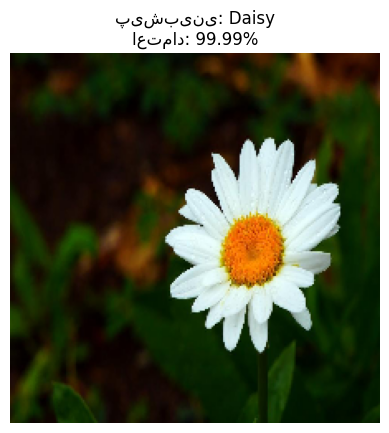

این گل احتمالاً: Daisy است (99.99%)
/kaggle/input/pictotest/image (2).jpg

نتایج پیش‌بینی برای: image (2).jpg
 1. ColtsFoot            → 0.9262 (92.62%) پیش‌بینی نهایی
 2. Dandelion            → 0.0360 (3.60%) 
 3. Daisy                → 0.0196 (1.96%) 
 4. Sunflower            → 0.0104 (1.04%) 
 5. ButterCup            → 0.0020 (0.20%) 
 6. Cowslip              → 0.0014 (0.14%) 
 7. Pansy                → 0.0011 (0.11%) 
 8. WindFlower           → 0.0009 (0.09%) 
 9. Iris                 → 0.0008 (0.08%) 
10. tulip                → 0.0004 (0.04%) 


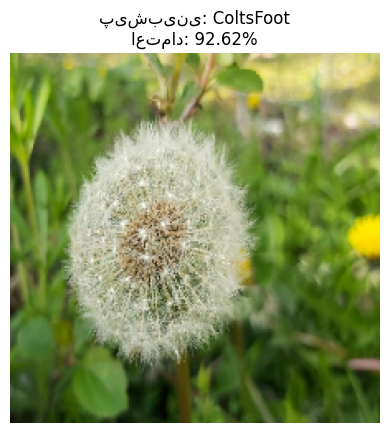

این گل احتمالاً: ColtsFoot است (92.62%)
/kaggle/input/pictotest/image (3).jpg

نتایج پیش‌بینی برای: image (3).jpg
 1. Bluebell             → 0.9987 (99.87%) پیش‌بینی نهایی
 2. LilyValley           → 0.0004 (0.04%) 
 3. Snowdrop             → 0.0001 (0.01%) 
 4. Iris                 → 0.0001 (0.01%) 
 5. Crocus               → 0.0001 (0.01%) 
 6. WindFlower           → 0.0001 (0.01%) 
 7. Tigerlily            → 0.0001 (0.01%) 
 8. Fritillary           → 0.0001 (0.01%) 
 9. Pansy                → 0.0001 (0.01%) 
10. tulip                → 0.0001 (0.01%) 


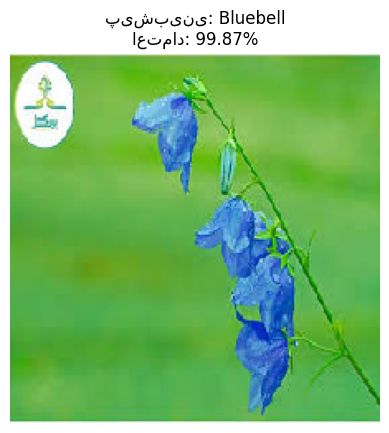

این گل احتمالاً: Bluebell است (99.87%)
/kaggle/input/pictotest/image (4).jpg

نتایج پیش‌بینی برای: image (4).jpg
 1. Snowdrop             → 0.9959 (99.59%) پیش‌بینی نهایی
 2. LilyValley           → 0.0014 (0.14%) 
 3. Bluebell             → 0.0007 (0.07%) 
 4. Daffodil             → 0.0006 (0.06%) 
 5. WindFlower           → 0.0005 (0.05%) 
 6. tulip                → 0.0002 (0.02%) 
 7. Fritillary           → 0.0002 (0.02%) 
 8. Tigerlily            → 0.0001 (0.01%) 
 9. Sunflower            → 0.0001 (0.01%) 
10. Daisy                → 0.0001 (0.01%) 


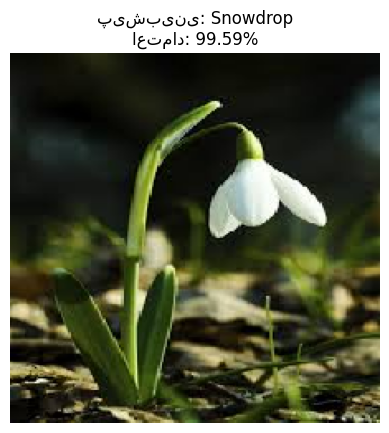

این گل احتمالاً: Snowdrop است (99.59%)
/kaggle/input/pictotest/image (5).jpg

نتایج پیش‌بینی برای: image (5).jpg
 1. Crocus               → 0.9933 (99.33%) پیش‌بینی نهایی
 2. Iris                 → 0.0058 (0.58%) 
 3. Sunflower            → 0.0004 (0.04%) 
 4. Pansy                → 0.0002 (0.02%) 
 5. ColtsFoot            → 0.0001 (0.01%) 
 6. tulip                → 0.0001 (0.01%) 
 7. Daffodil             → 0.0000 (0.00%) 
 8. Snowdrop             → 0.0000 (0.00%) 
 9. LilyValley           → 0.0000 (0.00%) 
10. Dandelion            → 0.0000 (0.00%) 


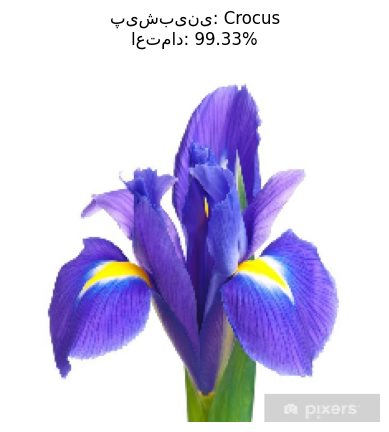

این گل احتمالاً: Crocus است (99.33%)


In [41]:
# --- تابع پیش‌بینی ---
def predict_flower(image_path, model, class_indices):
    # بارگذاری و پیش‌پردازش تصویر
    img = image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # پیش‌بینی
    predictions = model.predict(img_array, verbose=0)
    predictions = predictions.flatten()  # (17,) → مطمئن بشیم یک‌بعدیه

    # معکوس کردن class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}

    # پیش‌بینی نهایی
    predicted_idx = np.argmax(predictions)
    confidence = predictions[predicted_idx]
    predicted_class = idx_to_class[predicted_idx]

    # لیست مرتب‌شده احتمالات (۱۰ تای اول)
    sorted_indices = np.argsort(predictions)[::-1]
    
    print("\n" + "="*60)
    print(f"نتایج پیش‌بینی برای: {image_path.split('/')[-1]}")
    print("="*60)
    for rank, idx in enumerate(sorted_indices[:10], 1):
        name = idx_to_class[idx]
        prob = predictions[idx]
        star = "پیش‌بینی نهایی" if rank == 1 else ""
        print(f"{rank:2d}. {name:20} → {prob:.4f} ({prob:.2%}) {star}")
    print("="*60)

    return predicted_class, confidence, img
# --- استفاده ---
# class_indices از train_generator 
class_indices = train_generator.class_indices
for i in (1,2,3,4,5):
    # عکس خارجی
    external_image_path = "/kaggle/input/pictotest/image ("+str(i) +").jpg"  
    print(external_image_path)
    label, conf, img = predict_flower(external_image_path, model, class_indices)
    plt.imshow(img)
    plt.title(f"پیش‌بینی: {label}\nاعتماد: {conf:.2%}")
    plt.axis('off')
    plt.show()
    print(f"این گل احتمالاً: {label} است ({conf:.2%})")
